In [36]:
print("Hello, World!")


Hello, World!


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns
#Load the dataset


In [38]:
df_decl = pd.read_csv("data/raw/declarations.csv")

In [119]:
df_sum = pd.read_csv("data/raw/disaster_summaries.csv")

In [120]:
df_pa = pd.read_csv("data/raw/public_assistance.csv")

In [41]:
#df_decl = pd.read_parquet("direct_data_streaming/data/raw/declarations.parquet")

In [42]:
#df_DS = pd.read_parquet("direct_data_streaming/data/raw/disaster_summaries.parquet")

In [43]:
#df_PA = pd.read_parquet("direct_data_streaming/data/raw/public_assistance.parquet")

In [44]:
df_decl.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69895 entries, 0 to 69894
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   femaDeclarationString     69895 non-null  object
 1   disasterNumber            69895 non-null  int64 
 2   state                     69895 non-null  object
 3   declarationType           69895 non-null  object
 4   declarationDate           69895 non-null  object
 5   fyDeclared                69895 non-null  int64 
 6   incidentType              69895 non-null  object
 7   declarationTitle          69895 non-null  object
 8   ihProgramDeclared         69895 non-null  bool  
 9   iaProgramDeclared         69895 non-null  bool  
 10  paProgramDeclared         69895 non-null  bool  
 11  hmProgramDeclared         69895 non-null  bool  
 12  incidentBeginDate         69895 non-null  object
 13  incidentEndDate           69355 non-null  object
 14  disasterCloseoutDate  

In [45]:
df_decl = df_decl.drop_duplicates()

In [46]:
df_decl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69895 entries, 0 to 69894
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   femaDeclarationString     69895 non-null  object
 1   disasterNumber            69895 non-null  int64 
 2   state                     69895 non-null  object
 3   declarationType           69895 non-null  object
 4   declarationDate           69895 non-null  object
 5   fyDeclared                69895 non-null  int64 
 6   incidentType              69895 non-null  object
 7   declarationTitle          69895 non-null  object
 8   ihProgramDeclared         69895 non-null  bool  
 9   iaProgramDeclared         69895 non-null  bool  
 10  paProgramDeclared         69895 non-null  bool  
 11  hmProgramDeclared         69895 non-null  bool  
 12  incidentBeginDate         69895 non-null  object
 13  incidentEndDate           69355 non-null  object
 14  disasterCloseoutDate  

In [ ]:
df_pa["totalObligated"].describe()

count    1.000000e+03
mean     6.804190e+04
std      1.014903e+06
min      1.175900e+02
25%      2.602610e+03
50%      6.822025e+03
75%      1.736924e+04
max      3.118472e+07
Name: totalObligated, dtype: float64

In [48]:
df_decl.columns

Index(['femaDeclarationString', 'disasterNumber', 'state', 'declarationType',
       'declarationDate', 'fyDeclared', 'incidentType', 'declarationTitle',
       'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared',
       'hmProgramDeclared', 'incidentBeginDate', 'incidentEndDate',
       'disasterCloseoutDate', 'tribalRequest', 'fipsStateCode',
       'fipsCountyCode', 'placeCode', 'designatedArea',
       'declarationRequestNumber', 'lastIAFilingDate', 'incidentId', 'region',
       'designatedIncidentTypes', 'lastRefresh', 'hash', 'id'],
      dtype='object')

### Correct the data types

In [143]:
df_decl["declarationDate"] = pd.to_datetime(df_decl["declarationDate"], errors="coerce", utc=True)

df_decl["disasterNumber"] = df_decl["disasterNumber"].astype(str)
df_decl["incidentBeginDate"] = pd.to_datetime(df_decl["incidentBeginDate"], errors="coerce", utc=True)
df_decl["incidentEndDate"] = pd.to_datetime(df_decl["incidentEndDate"], errors="coerce", utc=True)
df_decl["lastRefresh"] = pd.to_datetime(df_decl["lastRefresh"], errors="coerce", utc=True)
df_decl["lastIAFilingDate"] = pd.to_datetime(df_decl["lastIAFilingDate"], errors="coerce", utc=True)
df_decl["disasterCloseoutDate"] = pd.to_datetime(df_decl["disasterCloseoutDate"], errors="coerce", utc=True)

In [50]:
df_decl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69895 entries, 0 to 69894
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   femaDeclarationString     69895 non-null  object             
 1   disasterNumber            69895 non-null  object             
 2   state                     69895 non-null  object             
 3   declarationType           69895 non-null  object             
 4   declarationDate           69895 non-null  datetime64[ns, UTC]
 5   fyDeclared                69895 non-null  int64              
 6   incidentType              69895 non-null  object             
 7   declarationTitle          69895 non-null  object             
 8   ihProgramDeclared         69895 non-null  bool               
 9   iaProgramDeclared         69895 non-null  bool               
 10  paProgramDeclared         69895 non-null  bool               
 11  hmProgramDeclar

### Getting the categorical columns

In [53]:
cols=['disasterNumber', 'state', 'incidentType', 'declarationDate',
       'incidentBeginDate', 'incidentEndDate', 'declarationType',
       'femaDeclarationString', 'fyDeclared', 'declarationTitle',
       'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared',
       'hmProgramDeclared', 'disasterCloseoutDate', 'tribalRequest',
       'fipsStateCode', 'fipsCountyCode', 'placeCode', 'designatedArea',
       'declarationRequestNumber', 'lastIAFilingDate', 'incidentId', 'region',
       'designatedIncidentTypes', 'lastRefresh', 'hash', 'id']

In [144]:
categorical_cols = df_decl.select_dtypes(include=["object", "category","string"]).columns.tolist()

numerical_cols = df_decl.select_dtypes(include=["number"]).columns.tolist()
date_cols = df_decl.select_dtypes(include=["datetime64"]).columns.tolist()
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)
print("Date columns:", date_cols)

Categorical columns: ['femaDeclarationString', 'disasterNumber', 'state', 'declarationType', 'incidentType', 'declarationTitle', 'designatedArea', 'designatedIncidentTypes', 'hash', 'id', 'season']
Numerical columns: ['fyDeclared', 'fipsStateCode', 'fipsCountyCode', 'placeCode', 'declarationRequestNumber', 'incidentId', 'region', 'disaster_duration', 'disaster_duration_days', 'year', 'month']
Date columns: []


In [55]:
print(df_decl.dtypes)

femaDeclarationString                    object
disasterNumber                           object
state                                    object
declarationType                          object
declarationDate             datetime64[ns, UTC]
fyDeclared                                int64
incidentType                             object
declarationTitle                         object
ihProgramDeclared                          bool
iaProgramDeclared                          bool
paProgramDeclared                          bool
hmProgramDeclared                          bool
incidentBeginDate           datetime64[ns, UTC]
incidentEndDate             datetime64[ns, UTC]
disasterCloseoutDate        datetime64[ns, UTC]
tribalRequest                              bool
fipsStateCode                             int64
fipsCountyCode                            int64
placeCode                                 int64
designatedArea                           object
declarationRequestNumber                

In [56]:
for col in categorical_cols:
    df_decl[col] = (
        df_decl[col]
        .astype(str)
        .str.upper()
        .str.strip()
    )

In [57]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df_decl[col].value_counts(dropna=False))


===== femaDeclarationString =====
femaDeclarationString
DR-4522-ME    443
EM-3458-TX    257
DR-4485-TX    257
DR-1239-TX    257
EM-3261-TX    255
             ... 
FM-5489-OK      1
FM-5491-OK      1
FM-5492-NM      1
FM-5500-OR      1
FM-5506-OR      1
Name: count, Length: 5178, dtype: int64

===== disasterNumber =====
disasterNumber
4522    443
3458    257
4485    257
1239    257
3261    255
       ... 
5489      1
5491      1
5492      1
5500      1
5506      1
Name: count, Length: 5178, dtype: int64

===== state =====
state
TX    5389
KY    3355
MO    2830
FL    2793
GA    2768
VA    2756
LA    2671
OK    2593
NC    2431
MS    2129
PR    2116
TN    2038
IA    1926
KS    1910
AR    1824
AL    1742
CA    1686
MN    1623
NE    1586
IN    1581
NY    1537
SD    1472
ND    1423
WV    1336
IL    1313
OH    1292
PA    1252
SC    1190
WA    1081
ME    1065
WI     895
MI     819
MT     679
CO     667
OR     646
NJ     627
NM     543
MD     471
MA     414
VT     405
ID     380
AK     355
AZ 

#### Calculate the incident duration feature

In [88]:
df_decl["incidentBeginDate"] = pd.to_datetime(
    df_decl["incidentBeginDate"],
    utc=True
)

df_decl["incidentEndDate"] = pd.to_datetime(
    df_decl["incidentEndDate"],
    utc=True,
    errors="coerce"
)
# Fill missing end dates (ongoing disasters)

today = pd.Timestamp.now(tz="UTC").normalize()
df_decl["incidentEndDate_filled"] = (
    df_decl["incidentEndDate"]
    .fillna(today))

# Compute duration
df_decl["disaster_duration_days"] = (
    df_decl["incidentEndDate_filled"]
    - df_decl["incidentBeginDate"]
).dt.days.clip(lower=1) # Ensure minimum duration of 1 day if end date is the same as begin date



# Invalid begin dates
df_decl.loc[
    df_decl["incidentBeginDate"].isna(),
    "disaster_duration_days"
] = pd.NA

In [89]:
print(df_decl["disaster_duration_days"].describe())

count    69895.000000
mean       199.430016
std        691.117698
min          1.000000
25%          3.000000
50%         13.000000
75%         41.000000
max      10087.000000
Name: disaster_duration_days, dtype: float64


In [ ]:
df_decl["incidentType"].unique()

array(['FIRE', 'SEVERE STORM', 'STRAIGHT-LINE WINDS', 'FLOOD',
       'HURRICANE', 'BIOLOGICAL', 'WINTER STORM', 'TORNADO',
       'TROPICAL STORM', 'EARTHQUAKE', 'TYPHOON', 'SNOWSTORM', 'FREEZING',
       'MUD/LANDSLIDE', 'COASTAL STORM', 'OTHER', 'SEVERE ICE STORM',
       'DAM/LEVEE BREAK', 'VOLCANIC ERUPTION', 'TROPICAL DEPRESSION',
       'TOXIC SUBSTANCES', 'CHEMICAL', 'TERRORIST', 'DROUGHT',
       'HUMAN CAUSE', 'FISHING LOSSES', 'TSUNAMI'], dtype=object)

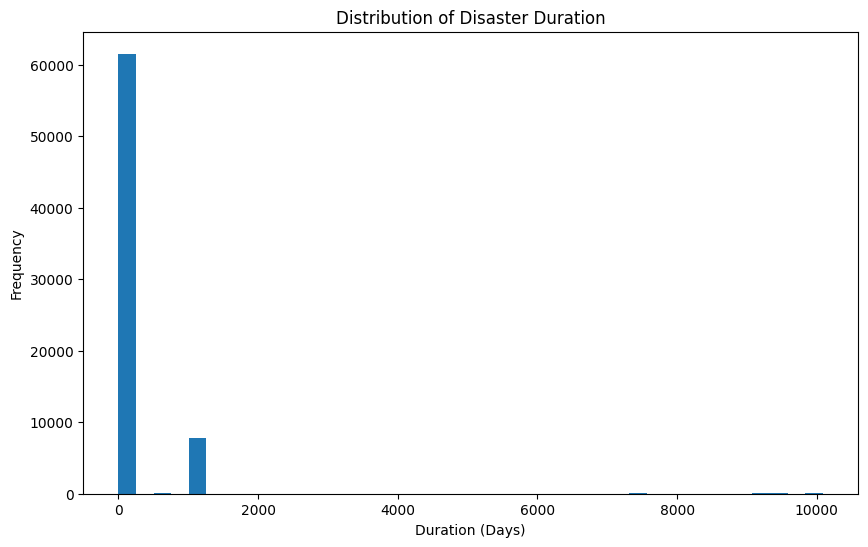

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df_decl["disaster_duration_days"].dropna(),
    bins=40
)

plt.title("Distribution of Disaster Duration")
plt.xlabel("Duration (Days)")
plt.ylabel("Frequency")

plt.show()

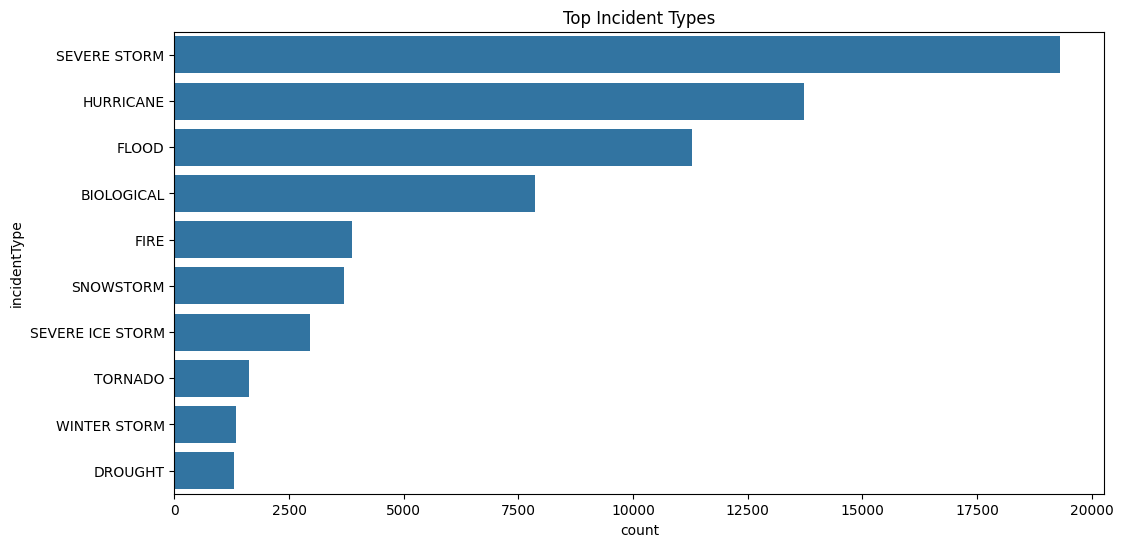

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.countplot(
    data=df_decl,
    y="incidentType",
    order=df_decl["incidentType"].value_counts().index[:10]
)

plt.title("Top Incident Types")
plt.show()

In [93]:
df_decl["incidentType"].value_counts()

incidentType
SEVERE STORM           19308
HURRICANE              13726
FLOOD                  11285
BIOLOGICAL              7857
FIRE                    3869
SNOWSTORM               3707
SEVERE ICE STORM        2956
TORNADO                 1623
WINTER STORM            1353
DROUGHT                 1292
TROPICAL STORM          1065
COASTAL STORM            637
OTHER                    314
FREEZING                 301
EARTHQUAKE               228
TYPHOON                  130
VOLCANIC ERUPTION         51
STRAIGHT-LINE WINDS       48
MUD/LANDSLIDE             44
FISHING LOSSES            42
DAM/LEVEE BREAK           13
TOXIC SUBSTANCES           9
CHEMICAL                   9
TSUNAMI                    9
TROPICAL DEPRESSION        7
HUMAN CAUSE                7
TERRORIST                  5
Name: count, dtype: int64

### Disaster Duration Boxplot

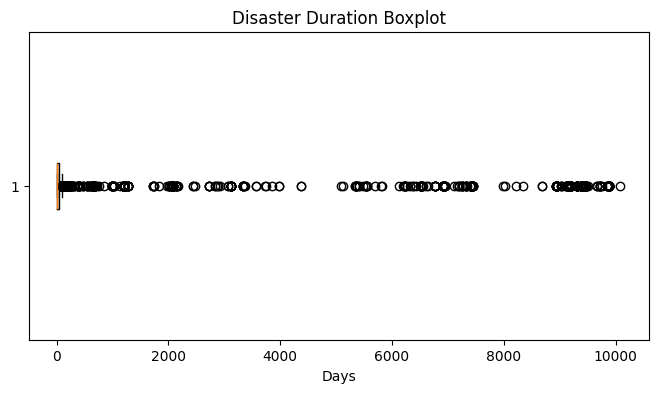

In [91]:
plt.figure(figsize=(8,4))

plt.boxplot(df_decl["disaster_duration_days"].dropna(), vert=False)

plt.title("Disaster Duration Boxplot")
plt.xlabel("Days")

plt.show()

### Disaster Duration by Incident Type

<Figure size 1200x600 with 0 Axes>

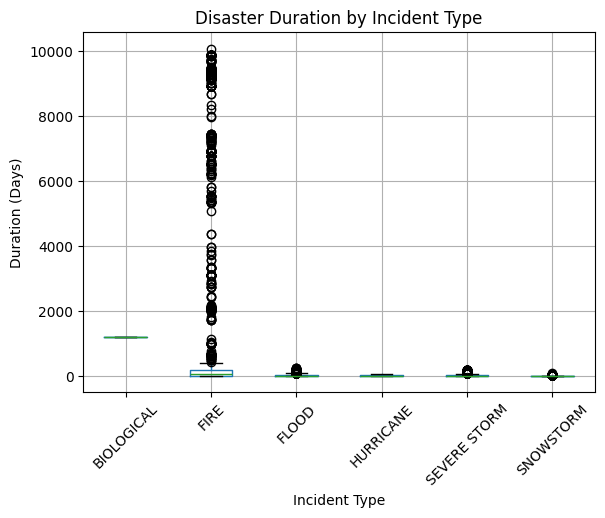

In [94]:
top_types = df_decl["incidentType"].value_counts().head(6).index

subset = df_decl[df_decl["incidentType"].isin(top_types)]

plt.figure(figsize=(12,6))

subset.boxplot(
    column="disaster_duration_days",
    by="incidentType",
    rot=45
)

plt.title("Disaster Duration by Incident Type")
plt.suptitle("")
plt.xlabel("Incident Type")
plt.ylabel("Duration (Days)")

plt.show()

### Average Disaster Duration Over Time

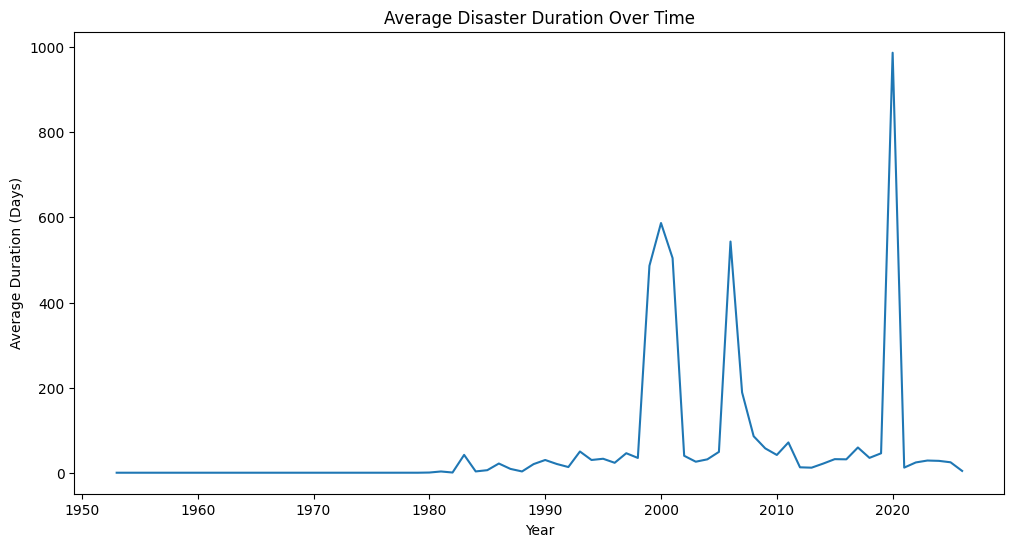

In [95]:
df_decl["year"] = df_decl["incidentBeginDate"].dt.year

avg_duration = (
    df_decl.groupby("year")["disaster_duration_days"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(avg_duration)

plt.title("Average Disaster Duration Over Time")
plt.xlabel("Year")
plt.ylabel("Average Duration (Days)")

plt.show()

In [96]:
df_decl["month"] = df_decl["incidentBeginDate"].dt.month

In [ ]:
df_decl["disaster_duration"] = (df_decl["incidentEndDate"] - df_decl["incidentBeginDate"]).dt.days

In [97]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df_decl["season"] = df_decl["month"].apply(get_season)

<Axes: xlabel='season'>

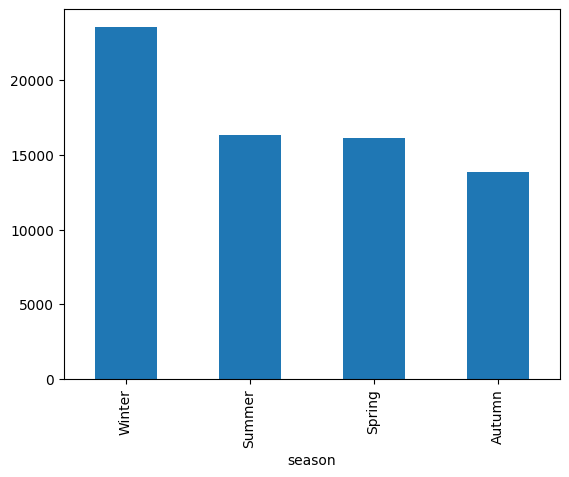

In [98]:
season_counts = df_decl["season"].value_counts()
season_counts.plot(kind="bar")

In [99]:
season_disaster = pd.crosstab(
    df_decl["season"],
    df_decl["incidentType"]
)

season_disaster

incidentType,BIOLOGICAL,CHEMICAL,COASTAL STORM,DAM/LEVEE BREAK,DROUGHT,EARTHQUAKE,FIRE,FISHING LOSSES,FLOOD,FREEZING,...,STRAIGHT-LINE WINDS,TERRORIST,TORNADO,TOXIC SUBSTANCES,TROPICAL DEPRESSION,TROPICAL STORM,TSUNAMI,TYPHOON,VOLCANIC ERUPTION,WINTER STORM
season,,,,,,,,,,,,,,,,,,,,,
Autumn,0,0,176,0,160,42,1022,24,1598,0,...,0,1,141,2,0,571,0,62,1,11
Spring,0,0,3,8,111,23,1119,18,4622,26,...,0,4,998,3,0,15,9,12,49,39
Summer,0,0,400,1,831,18,1526,0,2510,8,...,3,0,279,3,7,479,0,18,0,0
Winter,7857,9,58,4,190,145,202,0,2555,267,...,45,0,205,1,0,0,0,38,1,1303


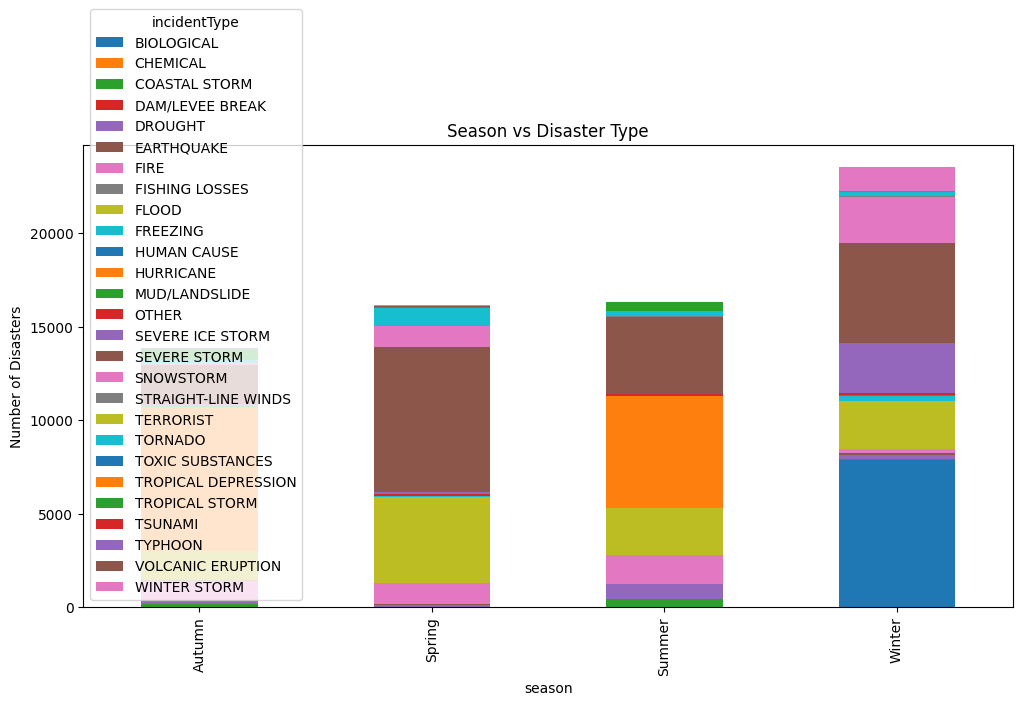

In [101]:
season_disaster.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Season vs Disaster Type")
plt.ylabel("Number of Disasters")
plt.show()

#### Calculate percentage disaster per seaeson

In [102]:
season_percent = season_disaster.div(
    season_disaster.sum(axis=1),
    axis=0
)

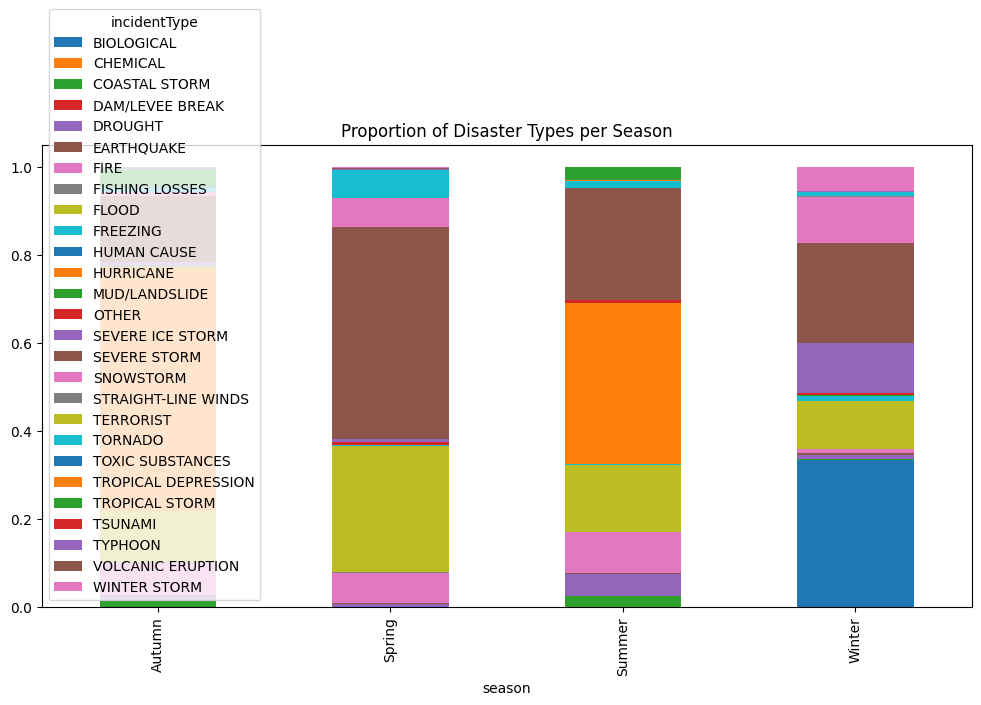

In [103]:
season_percent.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Proportion of Disaster Types per Season")
plt.show()

In [106]:

state_disaster_counts = pd.crosstab(
    df_decl["state"],
    df_decl["incidentType"]
)

### Top 10 disaster-prone States

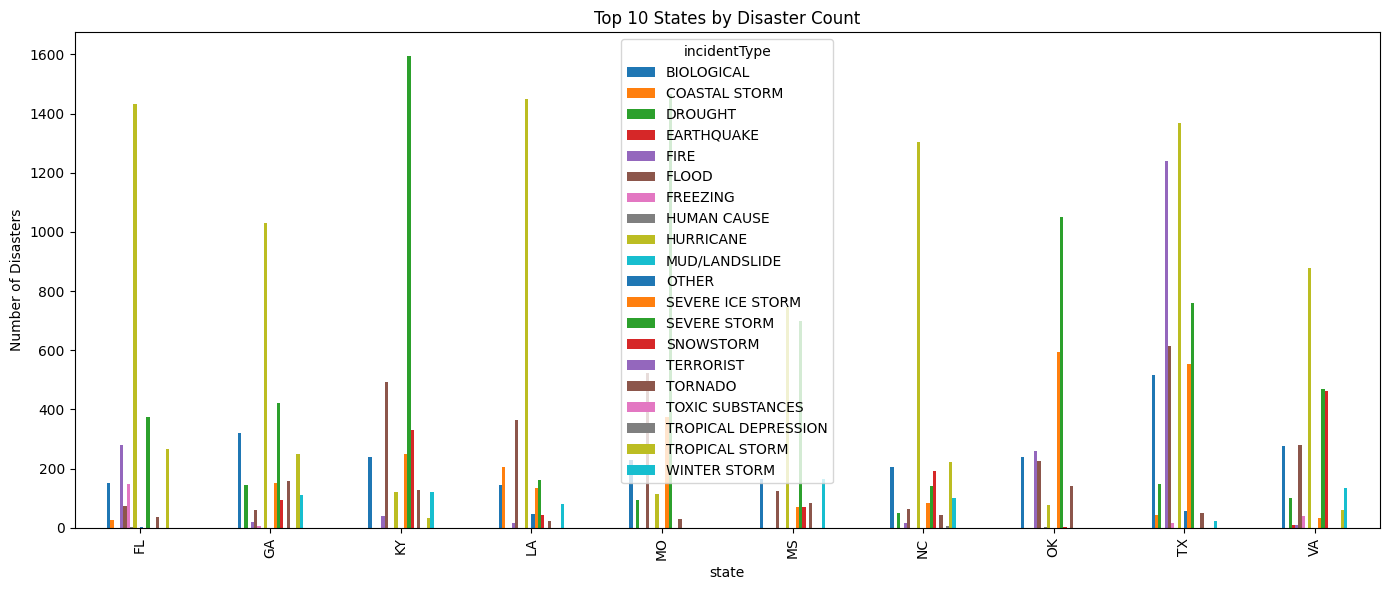

In [108]:
top_states = (
    df_decl["state"]
    .value_counts()
    .head(10)
    .index
)

filtered = df_decl[df_decl["state"].isin(top_states)]

state_disaster_counts = pd.crosstab(
    filtered["state"],
    filtered["incidentType"]
)

state_disaster_counts.plot(kind="bar", figsize=(14,6))
plt.title("Top 10 States by Disaster Count")
plt.ylabel("Number of Disasters")
plt.tight_layout()
plt.show()

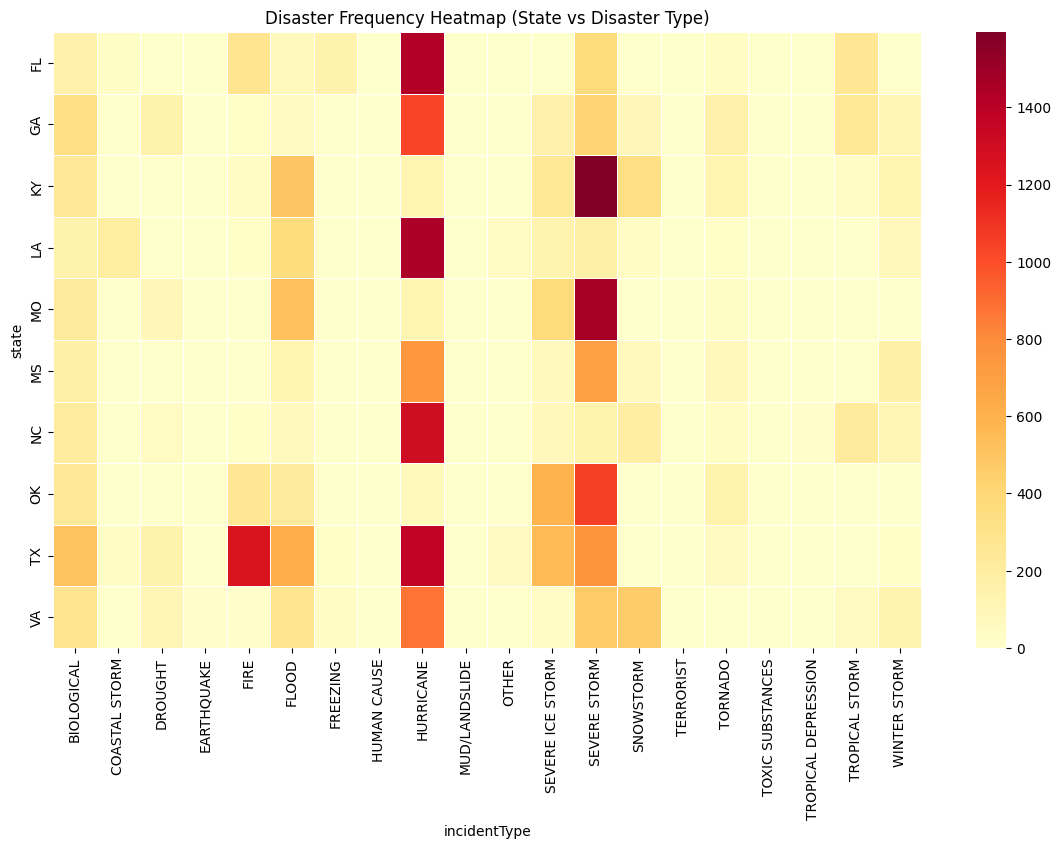

In [109]:
import seaborn as sns

plt.figure(figsize=(14,8))

sns.heatmap(
    state_disaster_counts,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Disaster Frequency Heatmap (State vs Disaster Type)")
plt.show()

In [157]:
df_decl.to_csv("data/clean_data/df_decl_clean.csv", index=False)

### Cleaning the Disaster summary data

In [121]:
df_sum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3939 entries, 0 to 3938
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   disasterNumber              3939 non-null   int64  
 1   totalNumberIaApproved       605 non-null    float64
 2   totalAmountIhpApproved      605 non-null    float64
 3   totalAmountHaApproved       549 non-null    float64
 4   totalAmountOnaApproved      603 non-null    float64
 5   totalObligatedAmountPa      2985 non-null   float64
 6   totalObligatedAmountCatAb   2724 non-null   float64
 7   totalObligatedAmountCatC2g  1548 non-null   float64
 8   paLoadDate                  2985 non-null   object 
 9   iaLoadDate                  605 non-null    object 
 10  totalObligatedAmountHmgp    2838 non-null   float64
 11  hash                        3939 non-null   object 
 12  lastRefresh                 3939 non-null   object 
 13  id                          3939 

In [141]:
df_sum["paLoadDate"] = pd.to_datetime(df_sum["paLoadDate"], errors="coerce", utc=True)
df_sum["disasterNumber"] = df_sum["disasterNumber"].astype(str)
df_sum["iaLoadDate"] = pd.to_datetime(df_sum["iaLoadDate"], errors="coerce", utc=True)


In [142]:
df_sum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3939 entries, 0 to 3938
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   disasterNumber              3939 non-null   object             
 1   totalNumberIaApproved       605 non-null    float64            
 2   totalAmountIhpApproved      605 non-null    float64            
 3   totalAmountHaApproved       549 non-null    float64            
 4   totalAmountOnaApproved      603 non-null    float64            
 5   totalObligatedAmountPa      2985 non-null   float64            
 6   totalObligatedAmountCatAb   2724 non-null   float64            
 7   totalObligatedAmountCatC2g  1548 non-null   float64            
 8   paLoadDate                  2985 non-null   datetime64[ns, UTC]
 9   iaLoadDate                  605 non-null    datetime64[ns, UTC]
 10  totalObligatedAmountHmgp    2838 non-null   float64         

In [125]:
df_sum = df_sum.dropna(subset=["disasterNumber"])

In [ ]:
df_sum.info()

: 

### Saving the clean df_sum data to a file

In [127]:
df_sum.to_csv("data/clean_data/df_sum_clean.csv", index=False)

### Cleaning the Public Assistance Data


In [128]:
df_pa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   disasterNumber         1000 non-null   int64  
 1   declarationDate        1000 non-null   object 
 2   incidentType           1000 non-null   object 
 3   pwNumber               1000 non-null   int64  
 4   applicationTitle       1000 non-null   object 
 5   applicantId            1000 non-null   object 
 6   damageCategoryCode     1000 non-null   object 
 7   damageCategoryDescrip  1000 non-null   object 
 8   projectStatus          1000 non-null   object 
 9   projectProcessStep     1000 non-null   object 
 10  projectSize            1000 non-null   object 
 11  county                 949 non-null    object 
 12  countyCode             1000 non-null   int64  
 13  stateAbbreviation      1000 non-null   object 
 14  stateNumberCode        1000 non-null   int64  
 15  proje

In [130]:
df_pa.columns


Index(['disasterNumber', 'declarationDate', 'incidentType', 'pwNumber',
       'applicationTitle', 'applicantId', 'damageCategoryCode',
       'damageCategoryDescrip', 'projectStatus', 'projectProcessStep',
       'projectSize', 'county', 'countyCode', 'stateAbbreviation',
       'stateNumberCode', 'projectAmount', 'federalShareObligated',
       'totalObligated', 'lastObligationDate', 'firstObligationDate',
       'mitigationAmount', 'gmProjectId', 'gmApplicantId', 'lastRefresh',
       'hash'],
      dtype='object')

In [131]:
df_sum.columns

Index(['disasterNumber', 'totalNumberIaApproved', 'totalAmountIhpApproved',
       'totalAmountHaApproved', 'totalAmountOnaApproved',
       'totalObligatedAmountPa', 'totalObligatedAmountCatAb',
       'totalObligatedAmountCatC2g', 'paLoadDate', 'iaLoadDate',
       'totalObligatedAmountHmgp', 'hash', 'lastRefresh', 'id'],
      dtype='object')

In [132]:
df_decl.columns

Index(['femaDeclarationString', 'disasterNumber', 'state', 'declarationType',
       'declarationDate', 'fyDeclared', 'incidentType', 'declarationTitle',
       'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared',
       'hmProgramDeclared', 'incidentBeginDate', 'incidentEndDate',
       'disasterCloseoutDate', 'tribalRequest', 'fipsStateCode',
       'fipsCountyCode', 'placeCode', 'designatedArea',
       'declarationRequestNumber', 'lastIAFilingDate', 'incidentId', 'region',
       'designatedIncidentTypes', 'lastRefresh', 'hash', 'id',
       'disaster_duration', 'incidentEndDate_filled', 'disaster_duration_days',
       'year', 'month', 'season'],
      dtype='object')

In [133]:
df_decl['disasterNumber'].dtype
df_pa['disasterNumber'].dtype
df_sum['disasterNumber'].dtype

dtype('O')

In [134]:
df_decl['disasterNumber'] = df_decl['disasterNumber'].astype(str)
df_pa['disasterNumber'] = df_pa['disasterNumber'].astype(str)
df_sum['disasterNumber'] = df_sum['disasterNumber'].astype(str)

In [136]:
print(df_decl['disasterNumber'].dtype)
print(df_pa['disasterNumber'].dtype)
print(df_sum['disasterNumber'].dtype)

object
object
object


In [137]:
df_pa["damageCategoryDescrip"].unique()

array(['Emergency Protective Measures',
       'Parks, Recreational Facilities, and Other Items',
       'Buildings and Equipment', 'Roads and Bridges', 'Debris Removal',
       'Direct Administrative Costs', 'Utilities', 'Management Costs',
       'Emergency Work Donated Resources', 'Water Control Facilities',
       'Section 324 Management Costs'], dtype=object)

In [145]:
value_countscat=df_pa["damageCategoryDescrip"].value_counts()
value_countscat

damageCategoryDescrip
Roads and Bridges                                  386
Emergency Protective Measures                      267
Buildings and Equipment                             90
Parks, Recreational Facilities, and Other Items     74
Debris Removal                                      72
Utilities                                           52
Management Costs                                    31
Direct Administrative Costs                         12
Water Control Facilities                            12
Emergency Work Donated Resources                     2
Section 324 Management Costs                         2
Name: count, dtype: int64

In [146]:

df_pa["declarationDate"] = pd.to_datetime(df_pa["declarationDate"], errors="coerce", utc=True)
df_pa["lastObligationDate"] = pd.to_datetime(df_pa["lastObligationDate"], errors="coerce", utc=True)
df_pa["firstObligationDate"] = pd.to_datetime(df_pa["firstObligationDate"], errors="coerce", utc=True)
df_pa["lastRefresh"] = pd.to_datetime(df_pa["lastRefresh"], errors="coerce", utc=True) 

In [147]:
df_pa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   disasterNumber         1000 non-null   object             
 1   declarationDate        1000 non-null   datetime64[ns, UTC]
 2   incidentType           1000 non-null   object             
 3   pwNumber               1000 non-null   int64              
 4   applicationTitle       1000 non-null   object             
 5   applicantId            1000 non-null   object             
 6   damageCategoryCode     1000 non-null   object             
 7   damageCategoryDescrip  1000 non-null   object             
 8   projectStatus          1000 non-null   object             
 9   projectProcessStep     1000 non-null   object             
 10  projectSize            1000 non-null   object             
 11  county                 949 non-null    object            

In [151]:
df_pa = df_pa.drop_duplicates()

In [152]:
df_pa.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   disasterNumber         1000 non-null   object             
 1   declarationDate        1000 non-null   datetime64[ns, UTC]
 2   incidentType           1000 non-null   object             
 3   pwNumber               1000 non-null   int64              
 4   applicationTitle       1000 non-null   object             
 5   applicantId            1000 non-null   object             
 6   damageCategoryCode     1000 non-null   object             
 7   damageCategoryDescrip  1000 non-null   object             
 8   projectStatus          1000 non-null   object             
 9   projectProcessStep     1000 non-null   object             
 10  projectSize            1000 non-null   object             
 11  county                 949 non-null    object            

In [153]:
df_pa.dropna(subset=["disasterNumber"], inplace=True)

In [154]:
df_pa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   disasterNumber         1000 non-null   object             
 1   declarationDate        1000 non-null   datetime64[ns, UTC]
 2   incidentType           1000 non-null   object             
 3   pwNumber               1000 non-null   int64              
 4   applicationTitle       1000 non-null   object             
 5   applicantId            1000 non-null   object             
 6   damageCategoryCode     1000 non-null   object             
 7   damageCategoryDescrip  1000 non-null   object             
 8   projectStatus          1000 non-null   object             
 9   projectProcessStep     1000 non-null   object             
 10  projectSize            1000 non-null   object             
 11  county                 949 non-null    object            

In [155]:
df_pa.to_csv("data/clean_data/df_pa_clean.csv", index=False )

In [156]:
print(df_decl["disasterNumber"].dtype)
print(df_pa["disasterNumber"].dtype)
print(df_sum["disasterNumber"].dtype)

object
object
object


### To avoid Memory explosion due to 1 to many joins, we will group the funding first before joining

 #### Join Strategy (Left join)

I  want to:

✅ Keep ALL disasters
✅ Add available funding info

In [ ]:
df_decl.shape

In [ ]:
df_sum.columns

In [ ]:
df_pa.shape

In [ ]:
df_PA_agg = (
    df_PA
    .groupby("disasterNumber")
    .agg({
        "totalObligated": "sum"
    })
    .reset_index()
)

In [ ]:
df_PA_agg.shape

In [ ]:
df_joined = df_decl.merge(
    df_PA_agg,
    on="disasterNumber",
    how="left"
)

In [ ]:
print(df_joined.shape)
df_joined.head()

In [ ]:
df_joined.columns

In [ ]:
df_PA.columns

In [ ]:
pa_agg = (
    df_PA.groupby("disasterNumber")
      .agg(
          total_obligated=("totalObligated", "sum"),
          project_count=("damageCategoryDescrip", "count"),
          unique_categories=("damageCategoryDescrip", "nunique")
      )
      .reset_index()
)

In [ ]:
pa_agg.head()

In [ ]:
df = df_decl.merge(
    pa_agg,
    on="disasterNumber",
    how="left"
)

In [ ]:
df["declarationDate"] = pd.to_datetime(
    df["declarationDate"],
    errors="coerce"
)

#### Create Time Features

In [ ]:
df["year"] = df["declarationDate"].dt.year
df["month"] = df["declarationDate"].dt.month
df["dayofyear"] = df["declarationDate"].dt.dayofyear

In [ ]:
df.columns

#### Disaster per state

In [ ]:
state_risk = (
    df.groupby("state")
      .size()
      .rename("historical_disaster_count_per_state")
)

df = df.merge(state_risk, on="state")

#### High Cost Disaster

In [ ]:
df["high_cost_disaster"] = (
    df["total_obligated"] > 10_000_000
).astype(int)

#### Handle Missing Values

In [ ]:
df["total_obligated"] = df["total_obligated"].fillna(0)
df["project_count"] = df["project_count"].fillna(0)

In [ ]:
features = df.drop(
    columns=[
        "declarationDate",
        "disasterNumber"
    ]
)

In [ ]:
features.columns


In [ ]:
features.to_parquet(
    "direct_python_streaming/data/feature/fema_features.parquet",
    index=False
)